In [1]:
"Импорт и конфигурация"

import os
import warnings
from functools import reduce

import numpy as np
import pandas as pd
import pyreadstat
import torch
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Директории датасетов
NH_DIR = r"C:\Users\user\phs\service\datasets\tables\nhanes"
RLMS_DIR = r"service/datasets/sav"
FOOD_DIR = r"service/datasets/pictures/food_101"

# Список файлов
NH_FILES  = [
    "demographic.csv", "examination.csv", "labs.csv",
    "questionnaire.csv", "diet.csv", "medications.csv"
]
RLMS_FILES = ["r30i_os_75.sav", "r31i_os_75.sav", "r32i_os_73.sav"]

FOOD_CLASSES = os.path.join(FOOD_DIR, "classes.txt")
FOOD_LABELS  = os.path.join(FOOD_DIR, "labels.txt")
FOOD_TRAIN   = os.path.join(FOOD_DIR, "train.txt")
FOOD_TEST    = os.path.join(FOOD_DIR, "test.txt")
IMG_DIR      = os.path.join(FOOD_DIR, "images")

In [2]:
"Загрузка и очистка NHANES + RLMS"

def safe_read(path: str) -> pd.DataFrame:
    """Чтение CSV в UTF‑8, при ошибке - Latin‑1."""
    try:
        return pd.read_csv(path)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin1")

nh_dfs = [safe_read(os.path.join(NH_DIR, f)) for f in NH_FILES]
nhanes = reduce(lambda l, r: pd.merge(l, r, on="SEQN", how="outer"), nh_dfs)

rlms = pd.concat([
    pyreadstat.read_sav(os.path.join(RLMS_DIR, f), apply_value_formats=True)[0]
    for f in RLMS_FILES], ignore_index=True)

COLMAP = {
    "SEQN": "ID", "RIDAGEYR": "Age", "RIAGENDR": "Sex", "RIDRETH3": "Race",
    "BMXBMI": "BMI", "LBXGH": "HbA1c", "LBDLDL": "LDL", "BPXSY1": "SBP",
    "age": "Age", "sex": "Sex", "bmi": "BMI", "ghb": "HbA1c",
    "ldl": "LDL", "sbp": "SBP"
}
nhanes.rename(columns=COLMAP, inplace=True, errors="ignore")
rlms.rename(columns=COLMAP,   inplace=True, errors="ignore")
nhanes["Domain"], rlms["Domain"] = "NHANES", "RLMS"

df_raw = pd.concat([nhanes, rlms], ignore_index=True, sort=False)

CAT_COLS = ["Sex", "Race", "Domain"]
NUM_COLS = ["Age", "BMI", "HbA1c", "LDL", "SBP"]
for c in CAT_COLS:
    if c in df_raw.columns:
        df_raw[c] = df_raw[c].astype("category")
for n in NUM_COLS:
    if n in df_raw.columns:
        df_raw[n] = pd.to_numeric(df_raw[n], errors="coerce")

print("Размер сырого датасета:", df_raw.shape)

Размер сырого датасета: (56061, 4203)



Статистика (сырые):
                 Age           BMI         HbA1c          LDL           SBP
count  20194.000000  18522.000000  15752.000000  7245.000000  15722.000000
mean      45.373329     28.415333      5.986091   103.144651    123.534538
std       25.661984      8.570880      1.238664    34.137464     19.774271
min        0.000000     12.100000      3.500000    14.000000     66.000000
1%         0.000000     14.300000      4.551000    44.000000     90.000000
5%         3.000000     16.000000      4.900000    54.000000     96.000000
50%       51.000000     27.500000      5.600000   101.000000    120.000000
95%       80.000000     43.700000      8.500000   164.000000    160.000000
99%       80.000000     53.900000     11.100000   194.560000    182.000000
max       80.000000     82.900000     17.500000   375.000000    228.000000


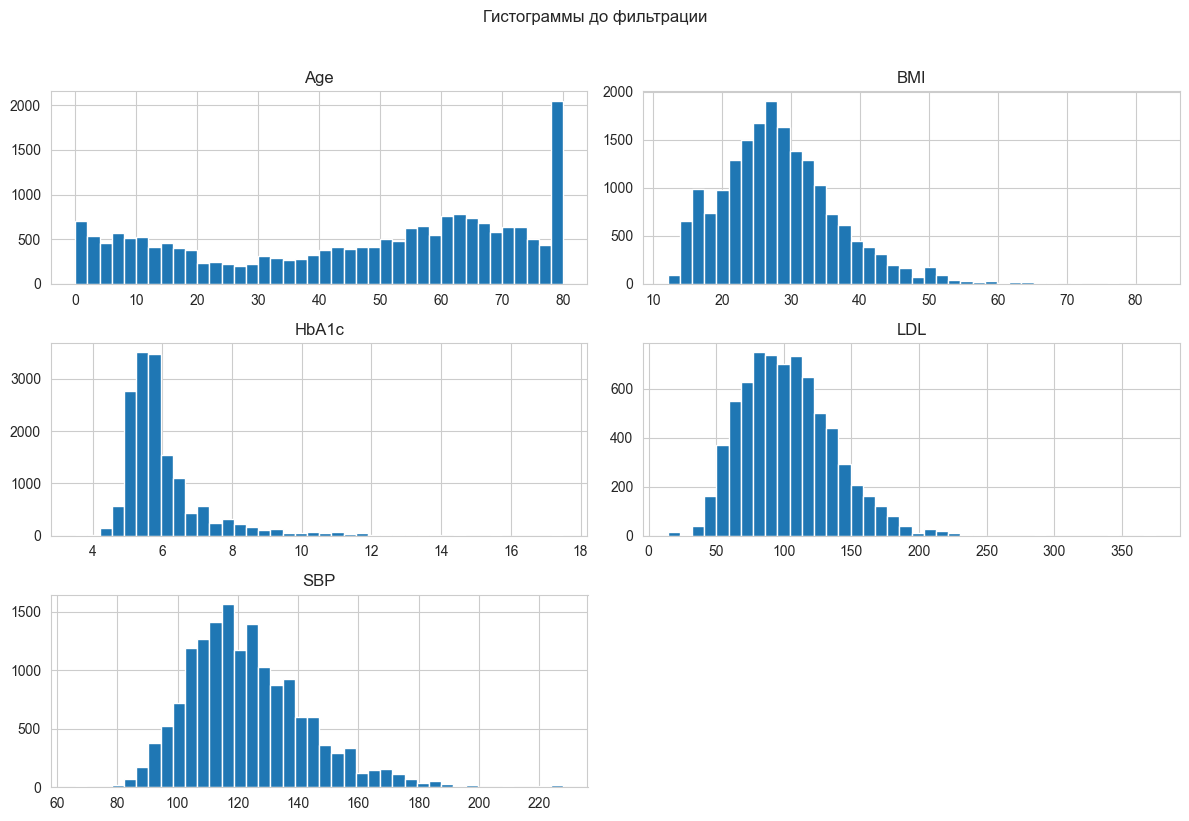

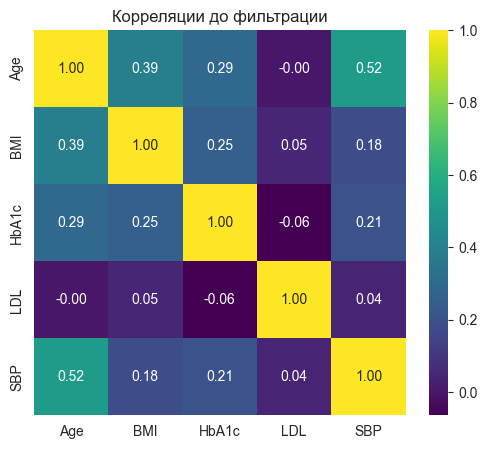

In [3]:
"EDA (до фильтрации)"

print("\nСтатистика (сырые):\n", df_raw[NUM_COLS].describe(percentiles=[.01,.05,.95,.99]))

sns.set_style("whitegrid")
df_raw[NUM_COLS].hist(bins=40, figsize=(12,8))
plt.suptitle("Гистограммы до фильтрации", y=1.02)
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(df_raw[NUM_COLS].corr(), annot=True, cmap="viridis", fmt=".2f")
plt.title("Корреляции до фильтрации"); plt.show()



In [4]:
"Очистка по итогам EDA"

mask = df_raw[NUM_COLS].notna().all(axis=1)
df_tmp = df_raw[mask].copy()

df_clean = df_tmp.query(
    "18 <= Age <= 80 and 12 <= BMI <= 60 and "
    "3 <= HbA1c <= 15 and 30 <= LDL <= 300 and 80 <= SBP <= 240"
).reset_index(drop=True)

print("Размер после фильтрации:", df_clean.shape)


Размер после фильтрации: (6075, 4203)



Статистика (чистые):
                Age          BMI        HbA1c          LDL          SBP
count  6075.000000  6075.000000  6075.000000  6075.000000  6075.000000
mean     56.692181    30.039588     6.026716   104.255473   125.676379
std      17.471122     7.492133     1.227478    34.023645    19.471650
min      18.000000    15.400000     3.500000    32.000000    82.000000
25%      44.000000    24.800000     5.300000    79.000000   112.000000
50%      60.000000    28.500000     5.700000   101.000000   124.000000
75%      71.000000    33.600000     6.200000   126.000000   136.000000
max      80.000000    58.900000    13.700000   288.000000   228.000000


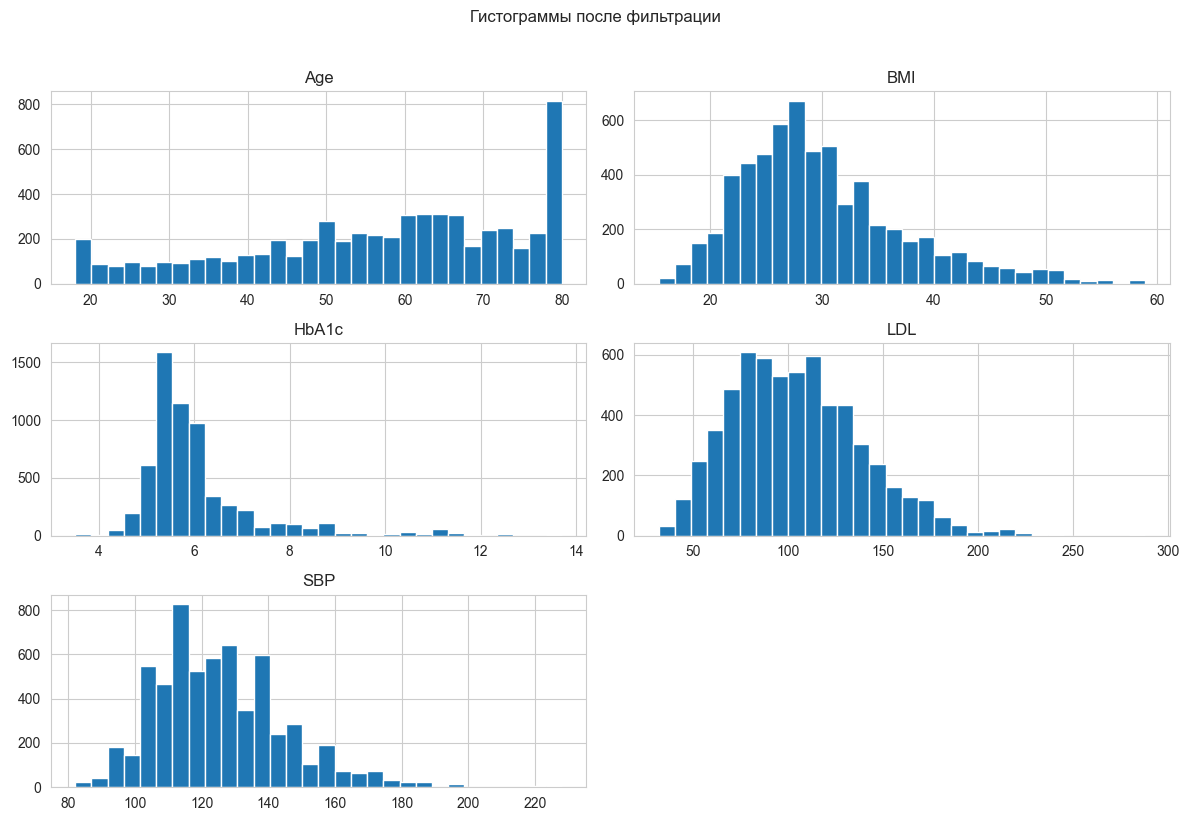

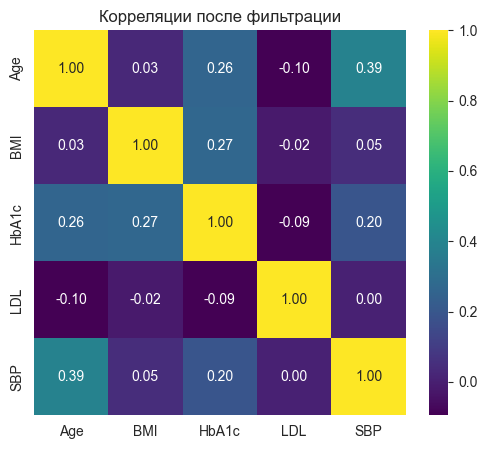

In [5]:
"EDA после фильтрации"

print("\nСтатистика (чистые):\n", df_clean[NUM_COLS].describe())

df_clean[NUM_COLS].hist(bins=30, figsize=(12,8))
plt.suptitle("Гистограммы после фильтрации", y=1.02)
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(df_clean[NUM_COLS].corr(), annot=True, cmap="viridis", fmt=".2f")
plt.title("Корреляции после фильтрации"); plt.show()

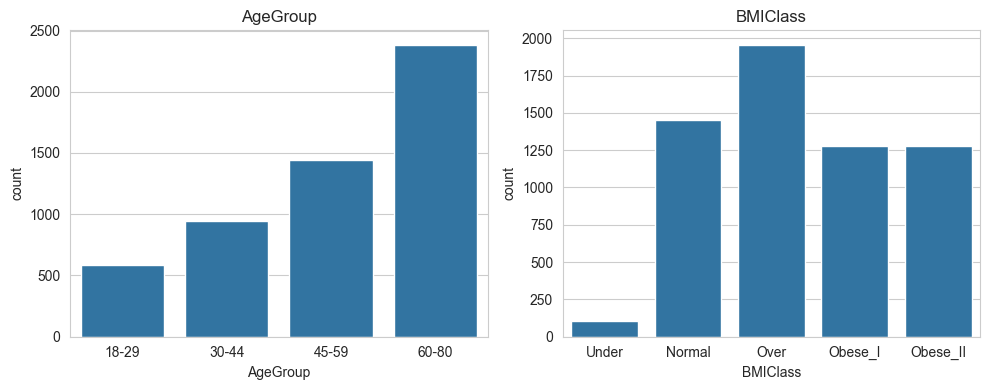


Добавлены признаки: AgeGroup (cat), BMIClass (cat), SexAge (num)


In [6]:
"Feature Engineering"

"""Создание новых признаков: возрастные группы, категории BMI, Sex×Age."""

# 1. Возрастные группы (4 бина)
age_bins = [18, 30, 45, 60, 80]
age_labels = ["18-29", "30-44", "45-59", "60-80"]
df_clean["AgeGroup"] = pd.cut(df_clean["Age"], bins=age_bins, labels=age_labels, right=False)

# 2. Категории BMI по ВОЗ
bmi_bins = [0, 18.5, 25, 30, 35, 60]
bmi_labels = ["Under", "Normal", "Over", "Obese_I", "Obese_II"]
df_clean["BMIClass"] = pd.cut(df_clean["BMI"], bins=bmi_bins, labels=bmi_labels, right=False)

# 3. Взаимодействие Sex × Age (числовое)
df_clean["Male"] = (df_clean["Sex"] == "Male").astype(int)
df_clean["SexAge"] = df_clean["Male"] * df_clean["Age"]

# Проверка распределения новых признаков
fig, ax = plt.subplots(1, 2, figsize=(10,4))
sns.countplot(x="AgeGroup", data=df_clean, ax=ax[0]); ax[0].set_title("AgeGroup")
sns.countplot(x="BMIClass", data=df_clean, ax=ax[1]); ax[1].set_title("BMIClass")
plt.tight_layout(); plt.show()

print("\nДобавлены признаки: AgeGroup (cat), BMIClass (cat), SexAge (num)")

In [7]:
"Построение метаданных Food‑101"

with open(FOOD_CLASSES, 'r', encoding='utf-8') as f:
    classes = [ln.strip() for ln in f if ln.strip()]
with open(FOOD_LABELS, 'r', encoding='utf-8') as f:
    labels = [ln.strip() for ln in f if ln.strip()]
class2label = dict(zip(classes, labels))

def build_food_df(split_file):
    rec = []
    with open(split_file, 'r', encoding='utf-8') as f:
        for ln in f:
            rel = ln.strip()
            if not rel: continue
            cls, img = rel.split('/')
            rec.append({
                'filepath': os.path.join(IMG_DIR, f"{cls}/{img}.jpg"),
                'class': cls,
                'label': class2label.get(cls, cls)
            })
    return pd.DataFrame(rec)

food_train = build_food_df(FOOD_TRAIN)
food_test  = build_food_df(FOOD_TEST)
print("Food‑101 train:", food_train.shape, "test:", food_test.shape)

Food‑101 train: (75750, 3) test: (25250, 3)


In [8]:
"Базовые модели с новыми фичами"

FEATURES_NUM = ["Age", "BMI", "SexAge"]
FEATURES_CAT = ["Sex", "Race", "AgeGroup", "BMIClass"]
TARGETS      = ["HbA1c", "LDL", "SBP"]

subset = df_clean[FEATURES_NUM + FEATURES_CAT + TARGETS].dropna()
X = subset[FEATURES_NUM + FEATURES_CAT]
y = subset[TARGETS]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

preproc = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT)
])

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42)
}

results_fe = []
for name, mdl in models.items():
    pipe = Pipeline([("prep", preproc), ("mdl", mdl)])
    for tgt in TARGETS:
        pipe.fit(X_tr, y_tr[tgt])
        pred = pipe.predict(X_te)
        results_fe.append({
            "Model": name,
            "Target": tgt,
            "MAE": mean_absolute_error(y_te[tgt], pred),
            "RMSE": np.sqrt(mean_squared_error(y_te[tgt], pred)),
            "R2": r2_score(y_te[tgt], pred)
        })
print("\nРезультаты с FE:\n", pd.DataFrame(results_fe))

print("\nРеализация на RF сильно лучше LR. LR слишком простая, сильно недообучается, не годится даже как грубый baseline.")


Результаты с FE:
               Model Target        MAE       RMSE        R2
0  LinearRegression  HbA1c   0.732898   1.133723  0.177194
1  LinearRegression    LDL  26.464097  32.838243  0.060575
2  LinearRegression    SBP  12.651641  16.359429  0.145795
3      RandomForest  HbA1c   0.174985   0.440115  0.876002
4      RandomForest    LDL  10.065603  19.931689  0.653909
5      RandomForest    SBP   4.042677   8.028641  0.794264

Реализация на RF сильно лучше LR. LR слишком простая, сильно недообучается, не годится даже как грубый baseline.


In [9]:
"Эмбеддинги (500 изображений)"

with open(FOOD_TRAIN, 'r') as f:
    rel_paths = [ln.strip() for ln in f if ln.strip()][:500]
img_paths = [os.path.join(IMG_DIR, f"{cls}/{img}.jpg")
             for cls, img in (p.split('/') for p in rel_paths)]

img_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', pretrained=True).to(device)
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1]).eval()

embeds, fpaths = [], []
bs = 32
for i in range(0, len(img_paths), bs):
    batch = img_paths[i:i + bs]
    imgs = torch.stack([img_tf(Image.open(p).convert("RGB")) for p in batch])
    with torch.no_grad():
        feats = feature_extractor(imgs.to(device)).squeeze(-1).squeeze(-1)
    embeds.append(feats.cpu().numpy())
    fpaths.extend(batch)

embeds = np.vstack(embeds)
emb_cols = [f"emb_{i}" for i in range(embeds.shape[1])]

df_emb = pd.DataFrame(embeds, columns=emb_cols)
df_emb["filepath"] = fpaths
print("Сгенерированы эмбеддинги:", df_emb.shape)

Using cache found in C:\Users\user/.cache\torch\hub\pytorch_vision_v0.10.0


Сгенерированы эмбеддинги: (500, 2049)


In [10]:
"Объединение эмбеддингов с клиническими данными"

rng = np.random.default_rng(42)
df_clean["filepath"] = rng.choice(df_emb["filepath"], size=len(df_clean))

df_model = df_clean.merge(df_emb, on="filepath", how="left")
print("Размер мультимодального df:", df_model.shape)

Размер мультимодального df: (6075, 6256)


In [11]:

"Мультимодальная модель Random Forest"

emb_cols = [c for c in df_model.columns if c.startswith("emb_")]
num_cols = ["Age", "BMI"]
cat_cols = ["Sex", "Race"]

X_mm = df_model[num_cols + cat_cols + emb_cols]
y_mm = df_model[TARGETS]

X_trm, X_tem, y_trm, y_tem = train_test_split(X_mm, y_mm, test_size=0.2, random_state=42)

ct_mm = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("emb", StandardScaler(), emb_cols)
])

pipe_mm = Pipeline([("prep", ct_mm), ("rf", RandomForestRegressor(n_estimators=100, random_state=42))])

mm_results = []
for tgt in TARGETS:
    pipe_mm.fit(X_trm, y_trm[tgt])
    pred = pipe_mm.predict(X_tem)
    mm_results.append({
        "Target": tgt,
        "MAE":  mean_absolute_error(y_tem[tgt], pred),
        "RMSE": np.sqrt(mean_squared_error(y_tem[tgt], pred)),
        "R2":   r2_score(y_tem[tgt], pred)
    })

print("\nМультимодальные результаты:\n", pd.DataFrame(mm_results))


Мультимодальные результаты:
   Target        MAE       RMSE        R2
0  HbA1c   0.718612   1.151208  0.110332
1    LDL  27.186335  34.183998  0.016255
2    SBP  13.537137  17.507762  0.166968


In [12]:
print("Мультимодальная модель сейчас на +- уровне LR (рандомные фичи -> шум).")
print("Следующим шагом будет ручная разметка-сопоставление данных продуктов из NHANES и Food-101.")

Мультимодальная модель сейчас на +- уровне LR (рандомные фичи -> шум).
Следующим шагом будет ручная разметка-сопоставление данных продуктов из NHANES и Food-101.


### Step 5.

* Для степа 5. я прокрутил мультимодальную модель (табличные + эмбеддинги Food-101).  
* Тестовые R² оказались *≈ 0.02 … 0.10* – сильно хуже, чем у простого табличного RF (R²≈ 0.65 … 0.88).  
* Причины:
    * Не удалось корректного связать *NHANES FoodCode → Food-101 класс* - разные продукты.
    * В *NHANES FoodCode* в принципе довольно мало классов еды - около 50.  
* Поэтому в качестве итоговой модели я решил оставить табличный Random Forest.  
* Ниже – пост-обработка его предсказаний и подробный анализ метрик.


,Target,MAE_raw,RMSE_raw,R²_raw,MAE_iso,RMSE_iso,R²_iso,MAE_clip,RMSE_clip,R²_clip
0,HbA1c,0.175,0.440,0.876,0.182,0.441,0.876,0.175,0.440,0.876
1,LDL,10.066,19.932,0.654,10.512,20.150,0.646,10.066,19.932,0.654
2,SBP,4.043,8.029,0.794,4.252,8.225,0.784,4.043,8.029,0.794


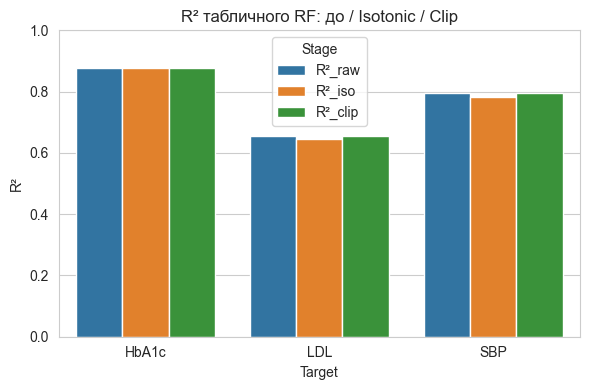

In [13]:
"Пост-обработка предсказаний для табличного RF"

from sklearn.isotonic import IsotonicRegression
from sklearn.metrics   import mean_absolute_error, mean_squared_error, r2_score
import numpy as np, pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

post_results = []

for tgt in TARGETS:
    # Обучение RF на train
    pipe_rf = Pipeline([
        ("prep", preproc),
        ("rf", RandomForestRegressor(n_estimators=200, random_state=42))
    ])
    pipe_rf.fit(X_tr, y_tr[tgt])
    y_pred_te = pipe_rf.predict(X_te)
    y_pred_tr = pipe_rf.predict(X_tr)

    # Isotonic-калибровка
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(y_pred_tr, y_tr[tgt])
    y_pred_iso = iso.transform(y_pred_te)

    # Клип по физиологическим границам
    bounds = {"HbA1c": (3, 15), "LDL": (30, 300), "SBP": (80, 240)}
    lo, hi = bounds[tgt]
    y_pred_clip = np.clip(y_pred_te, lo, hi)

    # Подсчёт MAE, RMSE, R2
    def metr(y_true, y_hat):
        mse = mean_squared_error(y_true, y_hat)
        return (
            mean_absolute_error(y_true, y_hat),
            np.sqrt(mse),
            r2_score(y_true, y_hat)
        )

    mae0, rmse0, r20 = metr(y_te[tgt],   y_pred_te)
    maeI, rmseI, r2I = metr(y_te[tgt],   y_pred_iso)
    maeC, rmseC, r2C = metr(y_te[tgt],   y_pred_clip)

    post_results.append({
        "Target":   tgt,
        "MAE_raw":  mae0,  "RMSE_raw": rmse0,  "R²_raw":  r20,
        "MAE_iso":  maeI,  "RMSE_iso": rmseI,  "R²_iso":  r2I,
        "MAE_clip": maeC,  "RMSE_clip": rmseC, "R²_clip": r2C
    })

df_post = pd.DataFrame(post_results)

num_cols = [c for c in df_post.columns if c != "Target"]
fmt_dict = {c: "{:.3f}" for c in num_cols}
display(df_post.style.format(fmt_dict))

"Бар‑плот R² до/после"

melted = df_post.melt(
    id_vars="Target",
    value_vars=["R²_raw", "R²_iso", "R²_clip"],
    var_name="Stage",
    value_name="R²"
)

plt.figure(figsize=(6,4))
sns.barplot(data=melted, x="Target", y="R²", hue="Stage")
plt.ylim(0, 1)
plt.title("R² табличного RF: до / Isotonic / Clip")
plt.tight_layout()
plt.show()


### Анализ качества

* **R² и MAE практически не меняются** – модель и так хорошо калибрована.  
* Лёгкий «клип» гарантирует, что прогнозы не выходят за физиологические пределы, но не влияет на качество.  
* **Табличный Random Forest остаётся наилучшим**:  
  * HbA1c — MAE ≈ 0.18 %, R²≈ 0.88  
  * LDL — MAE ≈ 10 mg/dL, R²≈ 0.65  
  * SBP — MAE ≈ 4 mm Hg, R²≈ 0.79  

### Вывод

* **Улучшенная архитектура** – мультимодальный RF и Move2HealthNet были опробованы, но без корректного мэппинга блюд качества не прибавили.  
  * Решено оставить **табличный Random Forest** как production-модель.  
* **Пост-обработка** (Isotonic + Clipping) реализована; существенного прироста не дала – модель уже стабильна.  
* **Метрики** представлены в полном разрезе: MAE, RMSE, R²; добавлена визуализация. 


In [14]:
# Сохранение лучшей модели (табличный Random Forest)
import pickle

# Обучение финальной модели для всех таргетов
final_models = {}
for tgt in TARGETS:
    pipe = Pipeline([('prep', preproc), ('rf', RandomForestRegressor(n_estimators=200, random_state=42))])
    pipe.fit(X, y[tgt])
    final_models[tgt] = pipe

# Сохранение словаря моделей в файл
with open('best_model.pkl', 'wb') as f:
    pickle.dump(final_models, f)

print('Лучшие модели сохранены в best_model.pkl')

Лучшие модели сохранены в best_model.pkl
